<a href="https://colab.research.google.com/github/giuspugl/astrophysics_lab/blob/main/astropy_cosmo_utils.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import astropy
import pylab as pl
from astropy import units as u
from astropy import constants as const
from astropy.coordinates import SkyCoord

import numpy as np

##  Cosmology

A useful feature of Astropy is related to [cosmological calculations](https://docs.astropy.org/en/stable/cosmology/index.html).  
The `astropy.cosmology` sub-package contains classes for representing cosmologies and utility functions for calculating commonly used quantities that depend on a cosmological model. This includes distances, ages, and lookback times corresponding to a measured redshift or the transverse separation corresponding to a measured angular separation.

astropy.cosmology.units extends the astropy.units sub-package, adding and collecting cosmological units and equivalencies, like  for keeping track of (dimensionless) factors of the Hubble constant.

In [ ]:
from astropy.cosmology import Planck18 as cosmo,z_at_value
from astropy.cosmology import FlatLambdaCDM
cosmo2= FlatLambdaCDM(Ob0=0,Om0=1, H0=70)

In [ ]:
z= np.logspace(-3, 2, 100)
a=  cosmo.scale_factor(z)

In [ ]:
print(cosmo2.age(0),cosmo.age(0))

9.312306873150371 Gyr 13.786885302009706 Gyr


Text(0.5, 0, 'redshift')

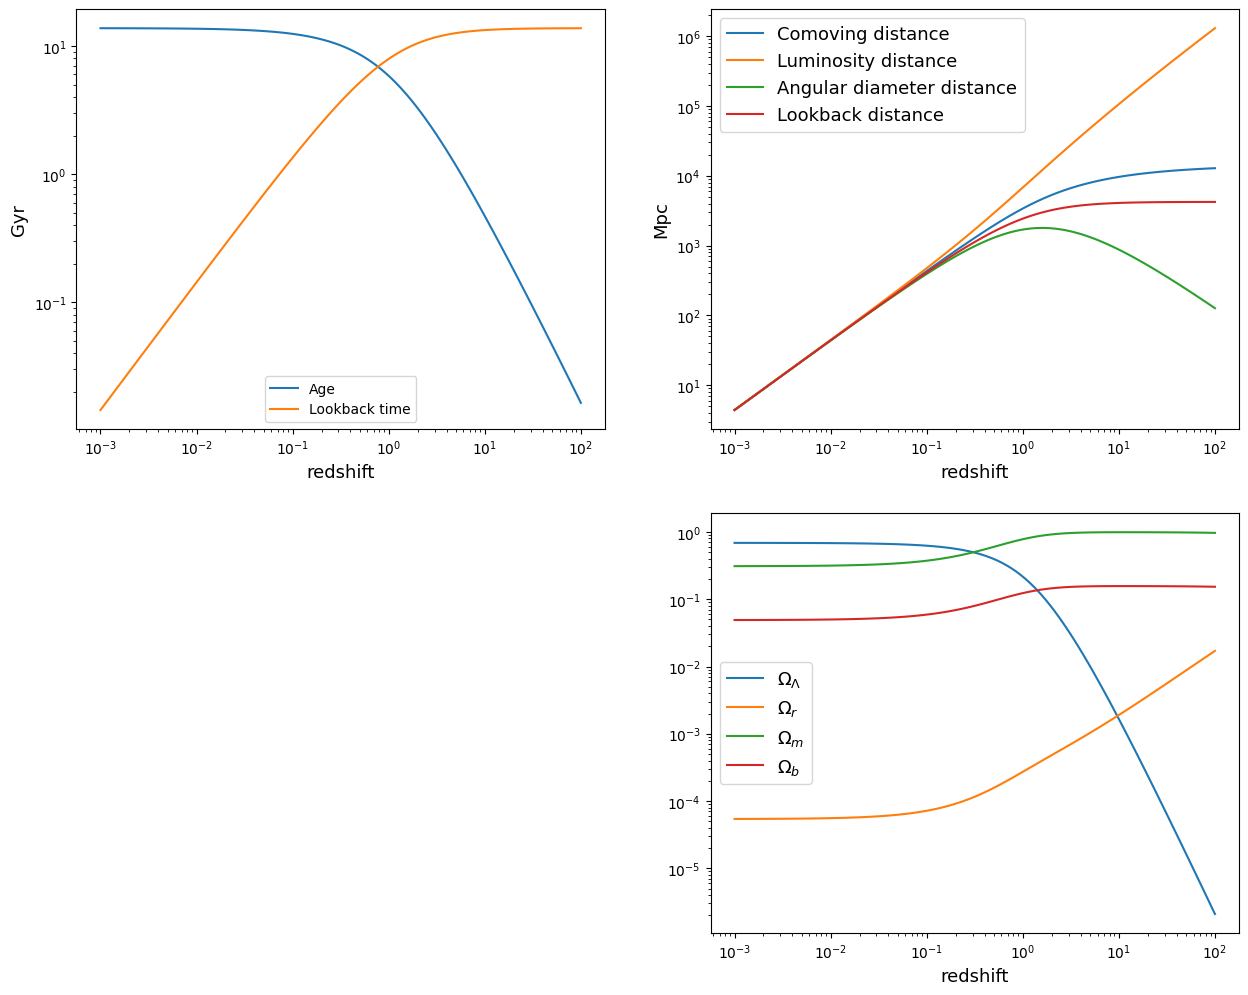

In [ ]:
pl.figure(figsize=(15,12))
pl.subplot(221)
pl.loglog(z, cosmo.age(z) , label='Age' )
pl.loglog(z, cosmo.lookback_time(z)  , label='Lookback time')
pl.legend()
pl.xlabel('redshift',fontsize=13)
pl.ylabel(cosmo.age(z).unit,fontsize=13)

pl.subplot(222)
pl.loglog(z, cosmo.comoving_distance(z) , label='Comoving distance' )
pl.loglog(z, cosmo.luminosity_distance(z)  , label='Luminosity distance')
pl.loglog(z, cosmo.angular_diameter_distance(z)  , label='Angular diameter distance')
pl.loglog(z, cosmo.lookback_distance(z) , label=r'Lookback distance' )
pl.xlabel('redshift',fontsize=13)
pl.ylabel(cosmo.comoving_distance(z).unit,fontsize=13)

pl.legend(fontsize=13)
pl.subplot(224)
pl.loglog(z, cosmo.Ode(z) , label=r'$\Omega_{\Lambda}$' )
pl.loglog(z, cosmo.Ogamma(z) , label=r'$\Omega_{r}$' )
pl.loglog(z, cosmo.Om(z)  , label=r'$\Omega_{m}$')
pl.loglog(z, cosmo.Ob(z)  , label=r'$\Omega_{b}$')
pl.legend(fontsize=13)
pl.xlabel('redshift',fontsize=13)


if you know a cosmological quantity and you want to know the redshift which it corresponds to, you can use `z_at_value()`.



In [ ]:
print(f"Redshift of M31 :{z_at_value(cosmo.luminosity_distance, 765*u.kpc) }" )
print(f"Redshift of an object in the Hubble flow :{z_at_value(cosmo.comoving_distance, cosmo.hubble_distance,) }" )

Redshift of M31 :0.0001726295870857113 redshift
Redshift of an object in the Hubble flow :1.4755193476506416 redshift
